# Task 1.a: Write the hypotheses explicitly

1.Null ($H_{0}$): Popularity rating has no effect on the chance of winning an award.
<br>
Alternative ($H_{1}$): A higher popularity rating increases the chance of winning an award.

2.Null ($H_{0}$): Explicitness of a song has no effect on the chance of winning an award.
<br>
Alternative ($H_{1}$): Explicit songs are less likely to win an award.

3.Null ($H_{0}$): Tempo has no effect on the chance of winning an award.
<br>
Alternative ($H_{1}$): Songs with a higher tempo are more likely to win an award.

# Task 1.b: Choose and justify approporiate test

**1.Regression Coefficient Test**
<br>
**Regression Coefficient Test** are used to determine if a **predictor variable** has a **statistically significant relationship** with a **dependent variable**. Since **Popularity Rating** is a **Continuous Variable** it will be our **predictor variable** and **Grammy Winner**, a **Categorical Variable** will be our **dependent variable**. This will test whether popularity significantly predicts the probability of winning.

**2.Chi-Square Test**
<br>
**Chi-Square Test** are used on **categorical data** to determine if there is a **significant relationship** between **two variables**, or if your observed data **matches** an **expected distribution**. We will compare two categorical variables in **Explicitness** and **Grammy Winner** to see whether the two have a relationship.

**3.Regression Coefficient Test**
<br>
**Regression Coefficient Test** are used to determine if a **predictor variable** has a **statistically significant relationship** with a **dependent variable**. Since **Tempo** is a **Continuous Variable** it will be our **predictor variable** and **Grammy Winner**, a **Categorical Variable** will be our **dependent variable**. This will test whether tempo significantly predicts the probability of winning.

# Task 1.c: Test Statistic, P-value, and Comparison

In [5]:
import pandas as pd
import statsmodels.api as sm
from scipy.stats import chi2_contingency
df = pd.read_csv("newdata.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'newdata.csv'

# Regression Coefficient Test of Popularity & Winner:

In [ ]:
x = sm.add_constant(df['popularity'])
y = df['winner']

model_popularity = sm.OLS(y, x).fit()

z_stat = model_popularity.tvalues['popularity']
p_value = model_popularity.pvalues['popularity']
alpha = 0.05

print("Regression Coefficient Test of Popularity & Winner: ")
print(f"Test Statistic (z): {z_stat:.3f}")
print(f"p-value: {p_value:.4f}")
print(f"Significance Level (α): {alpha}")

**Since the p-value of 0.0000 is less than our significance level of 0.05 we reject the null hypothesis of "Popularity rating has no effect on the chance of winning an award."**
<br>
**Popularity significantly predicts the chance of winning an award. In our dataset, songs with higher popularity ratings are much more likely to win awards.**

# Chi-Square test of Explictness & Winner:

In [ ]:
contingency = pd.crosstab(df['explicit'], df['winner'])
chi2, p_value, dof, expected = chi2_contingency(contingency)
alpha = 0.05

print("Chi-Square Test of Explictness & Winner:")
print(f"Chi-Square Statistic: {chi2:.3f}")
print(f"p-value: {p_value:.4f}")
print(f"Significance Level (α): {alpha}")

**Since the p-value of 0.1720 is greater than our significance level of 0.05 we fail to reject the null hypothesis of "Explicitness of a song has no effect on the chance of winning an award."**
<br>
**There is no significant relationship between explicitness and award outcome. In our dataset, explicit songs are neither more or less likely to win awards.**

# Regression Coefficient Test of Tempo & Winner:

In [ ]:
x = sm.add_constant(df['tempo'])
y = df['winner']

model_popularity = sm.OLS(y, x).fit()

z_stat = model_popularity.tvalues['tempo']
p_value = model_popularity.pvalues['tempo']
alpha = 0.05

print("Regression Coefficient Test of Tempo & Winner: ")
print(f"Test Statistic (z): {z_stat:.3f}")
print(f"p-value: {p_value:.4f}")
print(f"Significance Level (α): {alpha}")

**Since the p-value of 0.6287 is greater than our significance level of 0.05 we fail to reject the null hypothesis of "Tempo has no effect on the chance of winning an award."**
<br>
**Tempo does not significantly affect the chance of winning an award. Faster or slower songs have similar likelihoods of winning.**

# Task 2.b Feature Importance & Selection
- The approach that we chose to take with choosing feature importance was creating a correlation matrix (heat map) and taking note of how strongly (in either direction) each feature correlated with **award**
- The derived bar graph represents each feature's correlating relationship with the target variable.  

In [20]:
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("newdata (2).csv")
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

label_encoder = LabelEncoder()
df['artists'] = label_encoder.fit_transform(df['artists'])
df['track_name'] = label_encoder.fit_transform(df['track_name'])
df['track_genre'] = label_encoder.fit_transform(df['track_genre'])

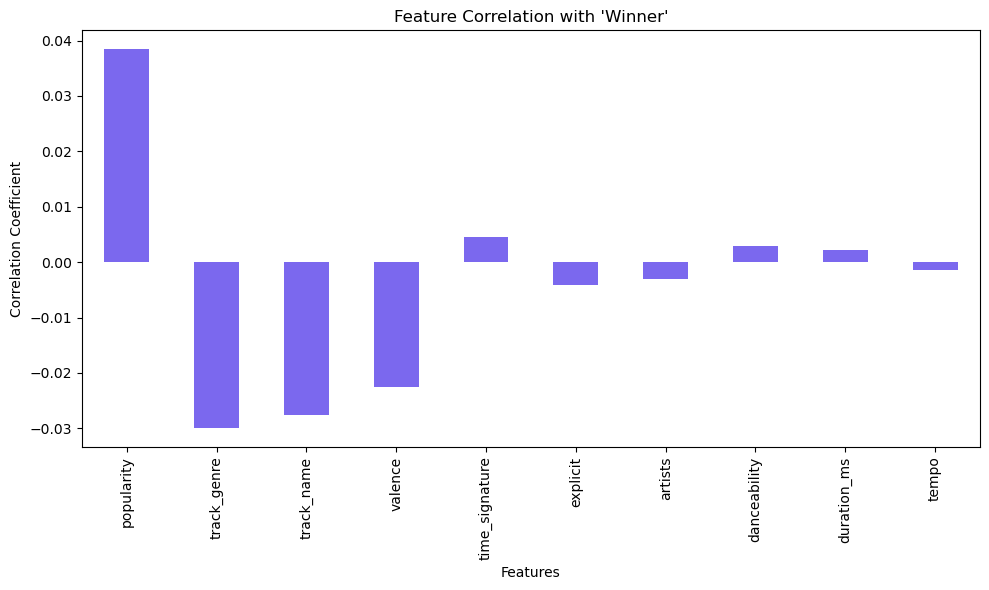

In [21]:
# Compute correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Get correlations with the target variable 'winner'
corr_with_winner = corr_matrix['winner'].drop('winner')

# Sort by absolute correlation value
corr_with_winner = corr_with_winner.sort_values(key=abs, ascending=False)
corr_with_winner

plt.figure(figsize=(10, 6))
corr_with_winner.plot(kind='bar', color='mediumslateblue')
plt.title("Feature Correlation with 'Winner'")
plt.xlabel("Features")
plt.ylabel("Correlation Coefficient")
plt.tight_layout()
plt.show()


Based on our bar chart, we can see that most features have weak linear relationships with whether a song wins an award. However, we'll keep numeric variables such as popularity, tempo, valence and genre since due to their numeric nature, they can still contribute predictive power. 

# 2.c Baseline Model -- Linear Regression

In [24]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, precision_score, recall_score

X = df[['popularity', 'danceability', 'valence', 'tempo', 'track_genre']]
y = df['winner']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
degrees = [1,2,3,5]
results = []

for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    # Predictions
    y_pred = model.predict(X_test_poly)
    
    # Regression metrics
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    # Convert to classification (0.5 threshold)
    y_class = (y_pred >= 0.5).astype(int)
    acc = accuracy_score(y_test, y_class)
    prec = precision_score(y_test, y_class, zero_division=0)
    rec = recall_score(y_test, y_class, zero_division=0)
    
    results.append((d, r2, rmse, acc, prec, rec))

results_df = pd.DataFrame(results, columns=['Degree', 'R2', 'RMSE', 'Accuracy', 'Precision', 'Recall'])
print(results_df)

   Degree        R2      RMSE  Accuracy  Precision  Recall
0       1  0.003370  0.165930  0.971566        0.0     0.0
1       2  0.010555  0.165331  0.971566        0.0     0.0
2       3  0.011625  0.165241  0.971566        0.0     0.0
3       5  0.012929  0.165132  0.971566        0.0     0.0


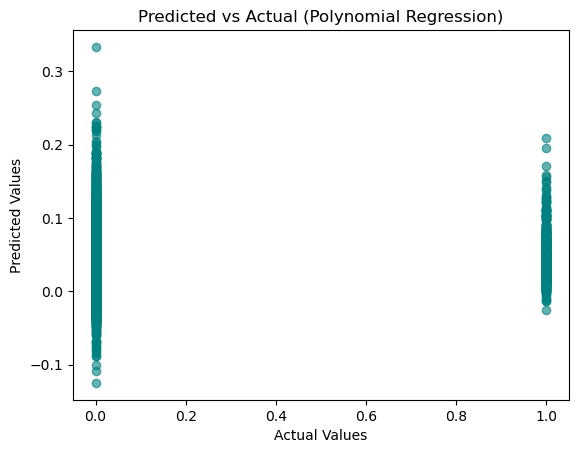

In [29]:
plt.scatter(y_test, y_pred, alpha=0.6, color='teal')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual (Polynomial Regression)")
plt.show()

We trained polynomial regression models with degrees 1, 2, 3, and 5 to predict whether a song wins an award based on its features. As degree increased, R² improved and RMSE decreased, suggesting slightly better model fit. **Degree 2** provided the best trade-off, because it offered noticeably better performance than degree 1 without excessive complexity.  
Because our target variable (winner) is binary, the linear regression model’s predictions cluster near 0 and 1, resulting in a vertically separated scatter plot, and so the actual visualization of predicted vs actual values isn't as informative as desired.